In [2]:
# Test Cell — Run this first to confirm everything works
import pandas as pd
import numpy as np
import matplotlib
import sklearn
import statsmodels
import pmdarima
import tensorflow as tf

print("="*45)
print("   SmartTea AI — Library Check")
print("="*45)
print(f"pandas       : {pd.__version__}")
print(f"numpy        : {np.__version__}")
print(f"matplotlib   : {matplotlib.__version__}")
print(f"scikit-learn : {sklearn.__version__}")
print(f"statsmodels  : {statsmodels.__version__}")
print(f"pmdarima     : {pmdarima.__version__}")
print(f"tensorflow   : {tf.__version__}")
print("="*45)
print("✅ ALL LIBRARIES READY!")
print()

# Load and check datasets
df1 = pd.read_csv('data/tea_demand_timeseries.csv')
df2 = pd.read_csv('data/tea_price_regression.csv')

print(f"Dataset 1 — tea_demand_timeseries.csv")
print(f"   Rows    : {len(df1):,}")
print(f"   Columns : {df1.columns.tolist()}")
print()
print(f"Dataset 2 — tea_price_regression.csv")
print(f"   Rows    : {len(df2):,}")
print(f"   Columns : {df2.columns.tolist()}")
print()
print("✅ BOTH DATASETS LOADED SUCCESSFULLY!")
print("✅ YOU ARE READY TO START THE AI WORK!")


   SmartTea AI — Library Check
pandas       : 3.0.3
numpy        : 2.4.6
matplotlib   : 3.11.0
scikit-learn : 1.9.0
statsmodels  : 0.14.6
pmdarima     : 2.1.1
tensorflow   : 2.21.0
✅ ALL LIBRARIES READY!

Dataset 1 — tea_demand_timeseries.csv
   Rows    : 5,475
   Columns : ['Date', 'TeaGrade', 'DemandKg', 'StockLevelKg', 'LowStockFlag', 'PricePerKgLKR', 'DeliveryDay', 'Month', 'DayOfWeek', 'DayOfYear', 'Quarter', 'IsWeekend', 'Warehouse']

Dataset 2 — tea_price_regression.csv
   Rows    : 1,065
   Columns : ['Date', 'Year', 'Month', 'Day', 'DayOfWeek', 'Quarter', 'IsWeekend', 'DayOfYear', 'GreenLeafPricePerKgLKR', 'GreenLeafQuantityKg', 'FirewoodCollectedKg', 'FirewoodCostPerKgLKR', 'TemperatureCelsius', 'RainfallMM', 'HeavyRainFlag', 'SupplierID', 'SupplierName', 'SupplierDelivered', 'SupplierQuantityKg', 'PromotionActive', 'MonthStartBonus', 'TotalDailyCostLKR', 'NextDayGreenLeafPrice', 'PriceLag1', 'PriceLag2', 'PriceLag3', 'PriceLag7', 'PriceLag14', 'PriceRollingMean7', 'PriceRoll

In [3]:
# ============================================================
# CELL 0 — Setup
# Run this FIRST before anything else
# ============================================================

import os

# Create plots folder to save all charts
os.makedirs('plots', exist_ok=True)

print("✅ Setup complete!")
print("✅ Plots folder ready!")
print("✅ You can now run Cell 1!")

✅ Setup complete!
✅ Plots folder ready!
✅ You can now run Cell 1!


In [4]:
# ============================================================
# CELL 1 — Import All Libraries
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

# --- SARIMA libraries ---
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import pmdarima as pm

# --- LSTM libraries ---
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

# --- Plot style ---
plt.style.use('seaborn-v0_8-darkgrid')

print("="*50)
print("   ✅ ALL LIBRARIES IMPORTED SUCCESSFULLY!")
print("="*50)
print(f"   TensorFlow  : {tf.__version__}")
print(f"   pmdarima    : {pm.__version__}")
print(f"   pandas      : {pd.__version__}")
print("="*50)
print("✅ Ready for Cell 2!")

   ✅ ALL LIBRARIES IMPORTED SUCCESSFULLY!
   TensorFlow  : 2.21.0
   pmdarima    : 2.1.1
   pandas      : 3.0.3
✅ Ready for Cell 2!


In [5]:
# ============================================================
# CELL 2 — Load Dataset
# ============================================================

# Load the CSV file 
df = pd.read_csv('data/tea_demand_timeseries.csv')

# Convert Date column to proper datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Print basic information
print("="*55)
print("   📊 DATASET OVERVIEW")
print("="*55)
print(f"   Total rows       : {len(df):,}")
print(f"   Total columns    : {len(df.columns)}")
print(f"   Date range       : {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"   Tea grades       : {sorted(df['TeaGrade'].unique().tolist())}")
print(f"   Missing values   : {df.isnull().sum().sum()}")
print("="*55)

print("\n📋 Column names:")
for col in df.columns:
    print(f"   {col}")

print("\n📋 First 5 rows:")
print(df.head())

print("\n📋 Basic statistics:")
print(df[['DemandKg','StockLevelKg','PricePerKgLKR']].describe().round(2))

print("\n✅ Dataset loaded! Ready for Cell 3!")

   📊 DATASET OVERVIEW
   Total rows       : 5,475
   Total columns    : 13
   Date range       : 2021-01-01 → 2023-12-31
   Tea grades       : ['BOP', 'BOPF', 'DUST', 'FNGS', 'OP']
   Missing values   : 0

📋 Column names:
   Date
   TeaGrade
   DemandKg
   StockLevelKg
   LowStockFlag
   PricePerKgLKR
   DeliveryDay
   Month
   DayOfWeek
   DayOfYear
   Quarter
   IsWeekend
   Warehouse

📋 First 5 rows:
        Date TeaGrade  DemandKg  StockLevelKg  LowStockFlag  PricePerKgLKR  \
0 2021-01-01      BOP     370.3        9591.3             0        1845.52   
1 2021-01-01     BOPF     311.7        8450.5             0        1584.96   
2 2021-01-01     DUST     269.4        7224.4             0        1560.04   
3 2021-01-01     FNGS     198.5        5398.4             0        1465.32   
4 2021-01-01       OP     139.6        3589.5             0        2610.79   

   DeliveryDay  Month  DayOfWeek  DayOfYear  Quarter  IsWeekend  \
0            1      1          4          1        1     

   📊 BOP TIME SERIES SUMMARY
   Total days    : 1095
   Start date    : 2021-01-01
   End date      : 2023-12-31
   Min demand    : 108.8 kg
   Max demand    : 495.5 kg
   Avg demand    : 319.0 kg
   Std deviation : 73.8 kg

📋 First 10 days of data:
            DemandKg
Date                
2021-01-01     370.3
2021-01-02     278.9
2021-01-03     246.7
2021-01-04     424.2
2021-01-05     407.2
2021-01-06     401.5
2021-01-07     430.5
2021-01-08     348.4
2021-01-09     245.2
2021-01-10     217.2


KeyError: '2021'

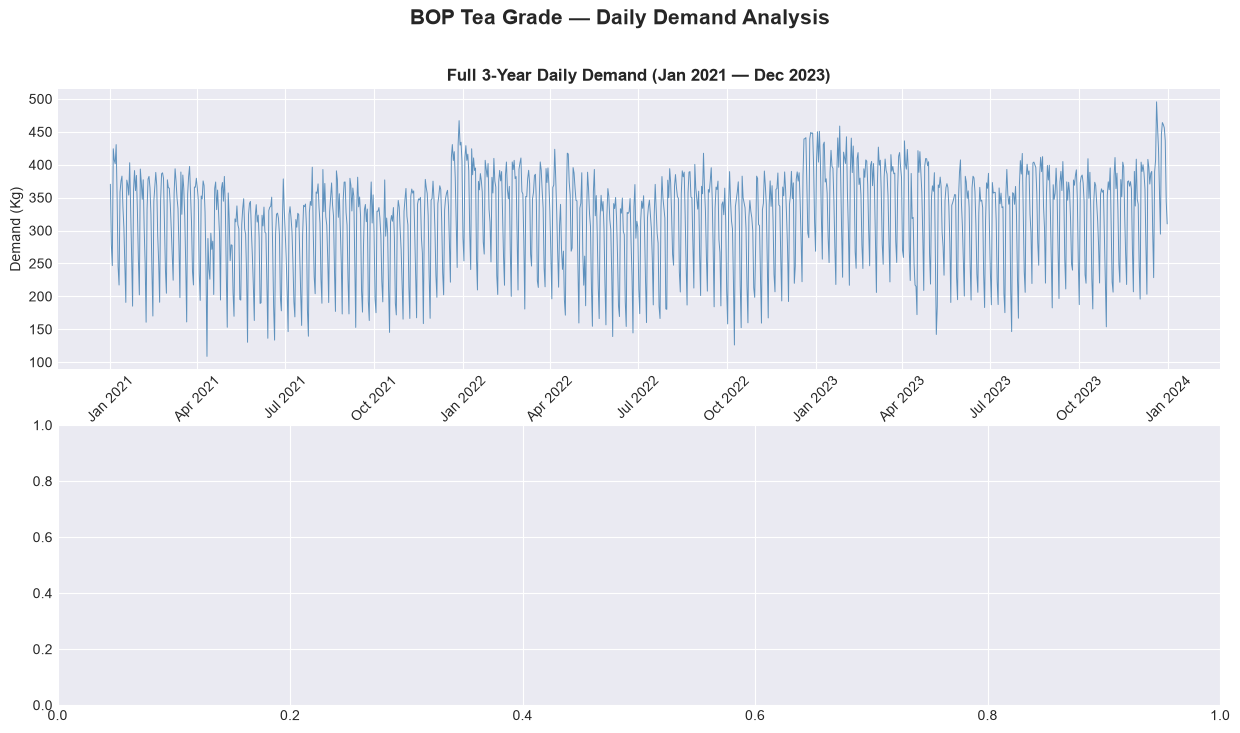

In [6]:
# ============================================================
# CELL 3 — Prepare BOP Tea Grade Time Series
#
# WHY BOP?
# BOP = Broken Orange Pekoe
# It is the HIGHEST demand grade in Sri Lankan tea factories
# Most important grade to forecast correctly
# ============================================================

# Filter for BOP grade only
bop_df = df[df['TeaGrade'] == 'BOP'].copy()

# Sort by date (oldest first)
bop_df = bop_df.sort_values('Date')

# Set Date as the index (required for time series)
bop_df = bop_df.set_index('Date')

# Set daily frequency
bop_df.index.freq = 'D'

# Keep only the DemandKg column as our time series
ts = bop_df[['DemandKg']].copy()

print("="*50)
print("   📊 BOP TIME SERIES SUMMARY")
print("="*50)
print(f"   Total days    : {len(ts)}")
print(f"   Start date    : {ts.index.min().date()}")
print(f"   End date      : {ts.index.max().date()}")
print(f"   Min demand    : {ts['DemandKg'].min():.1f} kg")
print(f"   Max demand    : {ts['DemandKg'].max():.1f} kg")
print(f"   Avg demand    : {ts['DemandKg'].mean():.1f} kg")
print(f"   Std deviation : {ts['DemandKg'].std():.1f} kg")
print("="*50)

print("\n📋 First 10 days of data:")
print(ts.head(10))

# ---- Plot the raw time series ----
fig, axes = plt.subplots(2, 1, figsize=(15, 8))
fig.suptitle('BOP Tea Grade — Daily Demand Analysis',
             fontsize=15, fontweight='bold')

# Full time series
axes[0].plot(ts.index, ts['DemandKg'],
             color='steelblue', linewidth=0.7, alpha=0.85)
axes[0].set_title('Full 3-Year Daily Demand (Jan 2021 — Dec 2023)',
                  fontweight='bold')
axes[0].set_ylabel('Demand (Kg)')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45)

# Zoomed in — just 2021 to show patterns clearly
ts_2021 = ts['2021']
axes[1].plot(ts_2021.index, ts_2021['DemandKg'],
             color='darkorange', linewidth=1.2)
axes[1].set_title('Zoomed: Year 2021 Only — See Weekly Pattern Clearly',
                  fontweight='bold')
axes[1].set_ylabel('Demand (Kg)')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
axes[1].xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig('plots/01_raw_time_series.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Plot saved → plots/01_raw_time_series.png")
print("✅ Ready for Cell 4!")

   STATIONARITY TESTS

📋 ADF Test — Original BOP Demand Series
   Test Statistic  : -1.750615
   p-value         : 0.405241
   Lags Used       : 22
   Observations    : 1072
   Critical Values:
      1%   : -3.436465
      5%   : -2.864240
      10%   : -2.568208
   ❌ RESULT: NOT STATIONARY (p=0.4052 > 0.05)
   ❌ Need to apply differencing first

📋 ADF Test — First-Differenced BOP Demand Series
   Test Statistic  : -9.132441
   p-value         : 0.000000
   Lags Used       : 22
   Observations    : 1071
   Critical Values:
      1%   : -3.436470
      5%   : -2.864242
      10%   : -2.568209
   ✅ RESULT: STATIONARY (p=0.0000 < 0.05)
   ✅ Good to use directly in SARIMA!



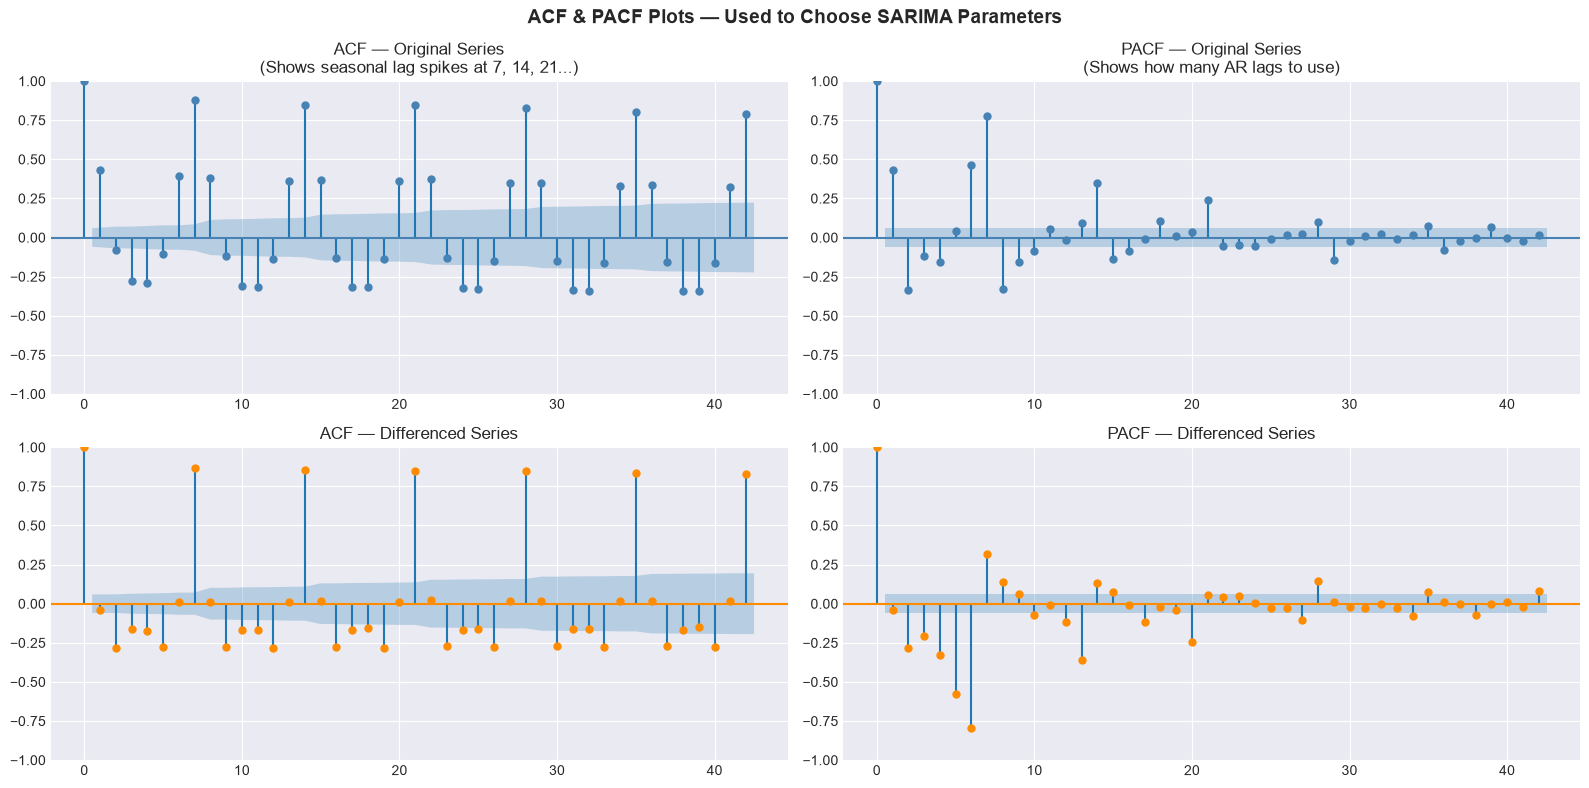

✅ ACF/PACF plots saved → plots/02_acf_pacf.png

   INTERPRETATION GUIDE
   ACF spikes at lag 7, 14, 21 → weekly seasonality ✅
   This confirms SARIMA with m=7 is the right choice

✅ Ready for Cell 5!


In [7]:
# ============================================================
# CELL 4 — Stationarity Test
#
# WHAT IS THIS?
# SARIMA requires the data to be "stationary"
# Stationary means: the data does not have a growing or
# shrinking trend — it stays at a similar level over time
#
# We use the ADF Test to check this
# ADF = Augmented Dickey-Fuller Test
#
# Rule:
#   If p-value < 0.05 → STATIONARY    ✅ good for SARIMA
#   If p-value > 0.05 → NOT STATIONARY ❌ need to difference
# ============================================================

def run_adf_test(series, title):
    """Run ADF stationarity test and print results clearly"""
    result = adfuller(series.dropna())

    print(f"📋 ADF Test — {title}")
    print(f"   Test Statistic  : {result[0]:.6f}")
    print(f"   p-value         : {result[1]:.6f}")
    print(f"   Lags Used       : {result[2]}")
    print(f"   Observations    : {result[3]}")
    print(f"   Critical Values:")
    for key, val in result[4].items():
        print(f"      {key}   : {val:.6f}")

    if result[1] < 0.05:
        print(f"   ✅ RESULT: STATIONARY (p={result[1]:.4f} < 0.05)")
        print(f"   ✅ Good to use directly in SARIMA!")
    else:
        print(f"   ❌ RESULT: NOT STATIONARY (p={result[1]:.4f} > 0.05)")
        print(f"   ❌ Need to apply differencing first")
    print()
    return result[1]

# Test 1 — Original series
print("="*55)
print("   STATIONARITY TESTS")
print("="*55)
print()
p_original = run_adf_test(ts['DemandKg'], 'Original BOP Demand Series')

# Test 2 — First difference (subtract yesterday from today)
ts_diff = ts['DemandKg'].diff().dropna()
p_diff  = run_adf_test(ts_diff, 'First-Differenced BOP Demand Series')

# ---- ACF and PACF plots ----
# ACF  = AutoCorrelation Function
# PACF = Partial AutoCorrelation Function
# These plots help us choose SARIMA parameters (p, d, q)
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
fig.suptitle('ACF & PACF Plots — Used to Choose SARIMA Parameters',
             fontsize=14, fontweight='bold')

# Original series ACF and PACF
plot_acf(ts['DemandKg'].dropna(),
         lags=42, ax=axes[0][0],
         title='ACF — Original Series\n(Shows seasonal lag spikes at 7, 14, 21...)',
         color='steelblue')

plot_pacf(ts['DemandKg'].dropna(),
          lags=42, ax=axes[0][1],
          title='PACF — Original Series\n(Shows how many AR lags to use)',
          color='steelblue')

# Differenced series ACF and PACF
plot_acf(ts_diff.dropna(),
         lags=42, ax=axes[1][0],
         title='ACF — Differenced Series',
         color='darkorange')

plot_pacf(ts_diff.dropna(),
          lags=42, ax=axes[1][1],
          title='PACF — Differenced Series',
          color='darkorange')

plt.tight_layout()
plt.savefig('plots/02_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ ACF/PACF plots saved → plots/02_acf_pacf.png")
print()
print("="*55)
print("   INTERPRETATION GUIDE")
print("="*55)
print("   ACF spikes at lag 7, 14, 21 → weekly seasonality ✅")
print("   This confirms SARIMA with m=7 is the right choice")
print("="*55)
print()
print("✅ Ready for Cell 5!")

   📊 TRAIN / TEST SPLIT SUMMARY
   Total days    : 1095
   Training days : 1065
   Test days     : 30

   Training period:
      Start  : 2021-01-01
      End    : 2023-12-01

   Test period (what we predict):
      Start  : 2023-12-02
      End    : 2023-12-31


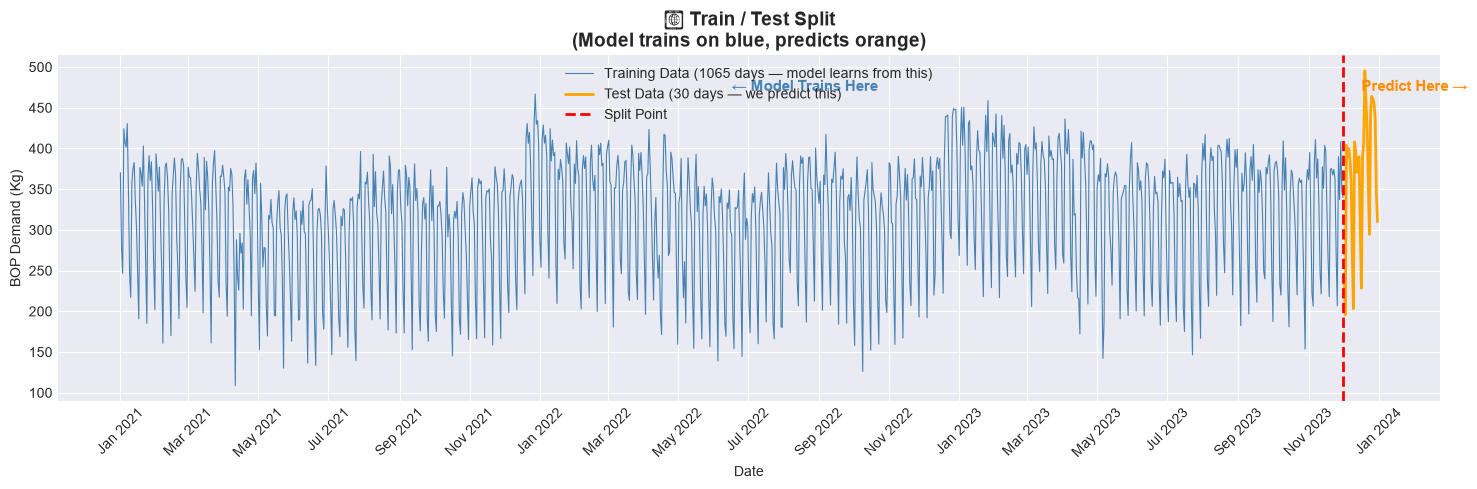


✅ Split plot saved → plots/03_train_test_split.png
✅ Ready for Cell 6!


In [8]:
# ============================================================
# CELL 5 — Train / Test Split
#
# WHAT IS THIS?
# We split our data into:
#   Training set → the model LEARNS from this
#   Test set     → we PRETEND we don't know this
#                  and see if the model can predict it
#
# We use the last 30 days as the test set
# This simulates predicting the next 30 days
# ============================================================

# Number of days to use as test set
TEST_DAYS = 30

# Split
train = ts.iloc[:-TEST_DAYS]   # Everything EXCEPT last 30 days
test  = ts.iloc[-TEST_DAYS:]   # Last 30 days only

print("="*55)
print("   📊 TRAIN / TEST SPLIT SUMMARY")
print("="*55)
print(f"   Total days    : {len(ts)}")
print(f"   Training days : {len(train)}")
print(f"   Test days     : {len(test)}")
print()
print(f"   Training period:")
print(f"      Start  : {train.index[0].date()}")
print(f"      End    : {train.index[-1].date()}")
print()
print(f"   Test period (what we predict):")
print(f"      Start  : {test.index[0].date()}")
print(f"      End    : {test.index[-1].date()}")
print("="*55)

# ---- Plot the split ----
fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(train.index, train['DemandKg'],
        color='steelblue', linewidth=0.8,
        label=f'Training Data ({len(train)} days — model learns from this)')

ax.plot(test.index, test['DemandKg'],
        color='orange', linewidth=2,
        label=f'Test Data ({len(test)} days — we predict this)')

ax.axvline(x=train.index[-1],
           color='red', linestyle='--',
           linewidth=2, label='Split Point')

# Add annotation
ax.annotate('← Model Trains Here',
            xy=(train.index[len(train)//2], ts['DemandKg'].max() * 0.95),
            fontsize=11, color='steelblue', fontweight='bold')

ax.annotate('Predict Here →',
            xy=(test.index[len(test)//2], ts['DemandKg'].max() * 0.95),
            fontsize=11, color='darkorange', fontweight='bold')

ax.set_title('📊 Train / Test Split\n(Model trains on blue, predicts orange)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('BOP Demand (Kg)')
ax.legend(fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('plots/03_train_test_split.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Split plot saved → plots/03_train_test_split.png")
print("✅ Ready for Cell 6!")

In [9]:
# ============================================================
# CELL 6 — SARIMA Auto Parameter Selection
#
# WHAT IS SARIMA?
# S  = Seasonal
# AR = AutoRegressive   (how past values affect future)
# I  = Integrated       (differencing to make stationary)
# MA = Moving Average   (how past errors affect future)
#
# Parameters we need to find:
#   (p, d, q)        = non-seasonal order
#   (P, D, Q, m)     = seasonal order
#   m = 7            = weekly seasonality (7 days)
#
# auto_arima finds the BEST parameters automatically
# by trying many combinations and picking the best one
# using AIC score (lower AIC = better model)
# ============================================================

print("="*55)
print("   🔄 SARIMA — AUTO PARAMETER SEARCH")
print("="*55)
print()
print("   auto_arima is now trying many parameter combinations")
print("   and finding the best one automatically...")
print("   ⏳ Please wait 2-4 minutes...")
print()

sarima_auto = pm.auto_arima(
    train['DemandKg'],
    seasonal=True,               # ← Enable seasonal component
    m=7,                         # ← Weekly seasonality (7 days)
    stepwise=True,               # ← Faster search method
    suppress_warnings=True,
    error_action='ignore',
    information_criterion='aic', # ← Use AIC to pick best model
    trace=True                   # ← Show each model being tried
)

print()
print("="*55)
print("   ✅ BEST SARIMA PARAMETERS FOUND!")
print("="*55)
print(f"   Non-seasonal order  (p, d, q) = {sarima_auto.order}")
print(f"   Seasonal order   (P, D, Q, m) = {sarima_auto.seasonal_order}")
print()
print("   What these mean:")
print(f"   p={sarima_auto.order[0]}  → uses {sarima_auto.order[0]} past value(s) for prediction")
print(f"   d={sarima_auto.order[1]}  → differenced {sarima_auto.order[1]} time(s) for stationarity")
print(f"   q={sarima_auto.order[2]}  → uses {sarima_auto.order[2]} past error(s) for correction")
print(f"   m=7  → weekly seasonal cycle")
print("="*55)
print()
print(sarima_auto.summary())
print()
print("✅ Parameters found! Ready for Cell 7!")

   🔄 SARIMA — AUTO PARAMETER SEARCH

   auto_arima is now trying many parameter combinations
   and finding the best one automatically...
   ⏳ Please wait 2-4 minutes...

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[7] intercept   : AIC=inf, Time=2.43 sec
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=12303.487, Time=0.04 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=10626.612, Time=0.83 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=inf, Time=0.53 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=12301.487, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[7] intercept   : AIC=12303.578, Time=0.03 sec
 ARIMA(1,1,0)(2,0,0)[7] intercept   : AIC=inf, Time=1.23 sec
 ARIMA(1,1,0)(1,0,1)[7] intercept   : AIC=inf, Time=1.43 sec
 ARIMA(1,1,0)(0,0,1)[7] intercept   : AIC=11631.654, Time=0.31 sec
 ARIMA(1,1,0)(2,0,1)[7] intercept   : AIC=inf, Time=2.77 sec
 ARIMA(0,1,0)(1,0,0)[7] intercept   : AIC=10803.896, Time=0.45 sec
 ARIMA(2,1,0)(1,0,0)[7] intercept   : AIC=inf, Time=nan sec
 ARIMA(1,1,1)(1,0,0

🔄 Fitting SARIMA model with best parameters...
   Please wait 30-60 seconds...

✅ SARIMA model fitted successfully!

✅ Forecast generated for 30 days!

📋 Forecast Preview (first 10 days):
            Actual_Kg  Predicted_Kg  Lower_95CI  Upper_95CI
Date                                                       
2023-12-02      246.2         264.2       206.0       322.5
2023-12-03      195.8         212.0       150.0       274.1
2023-12-04      403.9         372.6       307.0       438.2
2023-12-05      389.7         348.0       279.0       417.0
2023-12-06      399.9         378.4       306.2       450.6
2023-12-07      387.0         352.3       277.0       427.6
2023-12-08      362.9         343.3       265.1       421.6
2023-12-09      276.2         264.5       172.0       357.0
2023-12-10      203.2         209.3       111.6       307.0
2023-12-11      408.0         371.7       269.0       474.4

   📊 SARIMA — ACCURACY METRICS
   MAE  (avg error in kg)     : 60.588 kg
   RMSE (penalizes

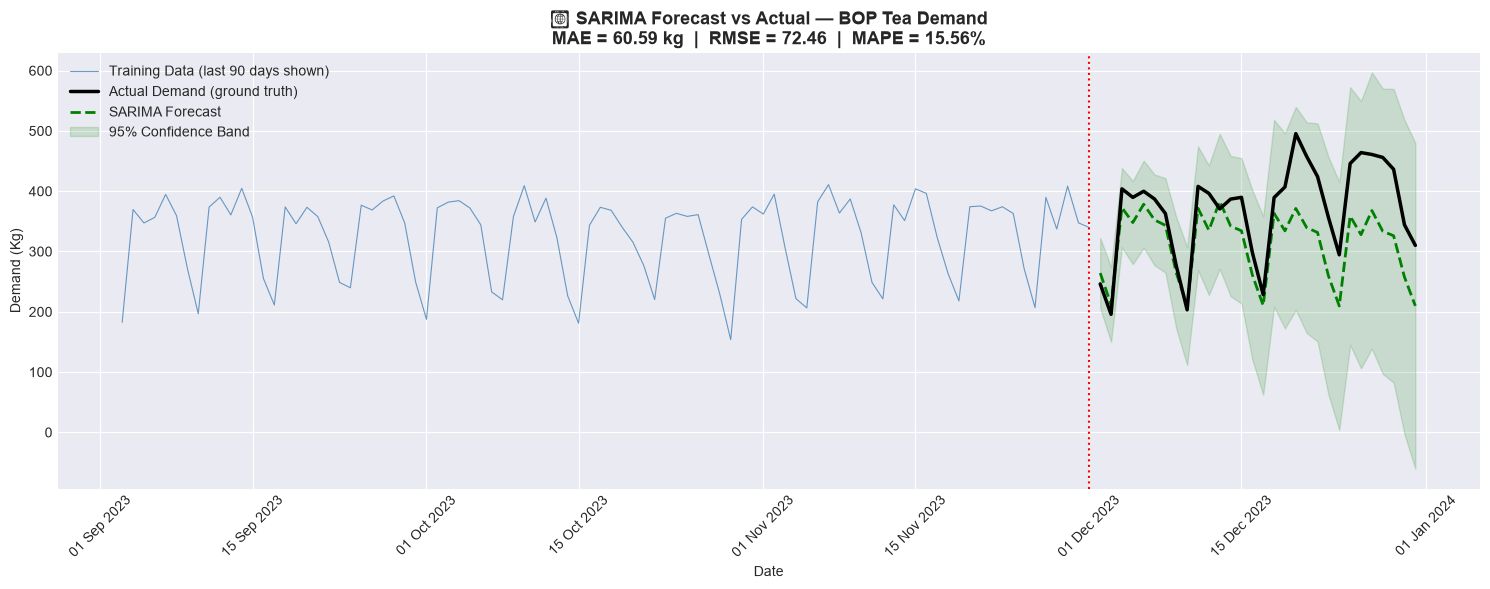


✅ SARIMA forecast plot saved → plots/04_sarima_forecast.png
✅ SARIMA COMPLETE! Ready for Cell 8!


In [10]:
# ============================================================
# CELL 7 — Fit SARIMA Model and Generate Forecast
# ============================================================

print("🔄 Fitting SARIMA model with best parameters...")
print("   Please wait 30-60 seconds...")
print()

# Fit the final SARIMA model using the best parameters found
sarima_model = SARIMAX(
    train['DemandKg'],
    order=sarima_auto.order,
    seasonal_order=sarima_auto.seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fitted = sarima_model.fit(disp=False)

print("✅ SARIMA model fitted successfully!")
print()

# Generate forecast for the next 30 days (test period)
sarima_forecast_obj = sarima_fitted.get_forecast(steps=TEST_DAYS)
sarima_pred         = sarima_forecast_obj.predicted_mean
sarima_conf_int     = sarima_forecast_obj.conf_int()

print("✅ Forecast generated for 30 days!")
print()
print("📋 Forecast Preview (first 10 days):")
preview = pd.DataFrame({
    'Date':          test.index[:10],
    'Actual_Kg':     test['DemandKg'].values[:10],
    'Predicted_Kg':  sarima_pred.values[:10].round(1),
    'Lower_95CI':    sarima_conf_int.iloc[:10, 0].round(1),
    'Upper_95CI':    sarima_conf_int.iloc[:10, 1].round(1)
})
preview = preview.set_index('Date')
print(preview.to_string())

# ============================================================
# Evaluation Metrics
# ============================================================
def evaluate(actual, predicted, model_name):
    """
    Calculate 3 key accuracy metrics:

    MAE  = Mean Absolute Error
           Average error in kg per day
           Lower = better

    RMSE = Root Mean Squared Error
           Similar to MAE but punishes big errors more
           Lower = better

    MAPE = Mean Absolute Percentage Error
           Error as a percentage (easier to understand)
           Lower = better
           Example: MAPE=5% means predictions are
                    off by 5% on average
    """
    mae  = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100

    print(f"\n{'='*50}")
    print(f"   📊 {model_name} — ACCURACY METRICS")
    print(f"{'='*50}")
    print(f"   MAE  (avg error in kg)     : {mae:.3f} kg")
    print(f"   RMSE (penalizes big errors): {rmse:.3f} kg")
    print(f"   MAPE (% error — key one!)  : {mape:.3f}%")
    print(f"{'='*50}")
    print(f"   📖 MAPE Interpretation:")
    if mape < 10:
        print(f"   ✅ Excellent forecast (MAPE < 10%)")
    elif mape < 20:
        print(f"   ✅ Good forecast (MAPE 10-20%)")
    elif mape < 30:
        print(f"   ⚠️  Acceptable forecast (MAPE 20-30%)")
    else:
        print(f"   ❌ Poor forecast (MAPE > 30%)")
    print(f"{'='*50}")

    return {
        'Model': model_name,
        'MAE':   round(mae,  4),
        'RMSE':  round(rmse, 4),
        'MAPE':  round(mape, 4)
    }

# Calculate SARIMA metrics
sarima_metrics = evaluate(
    test['DemandKg'].values,
    sarima_pred.values,
    'SARIMA'
)

# ---- Plot SARIMA Forecast ----
fig, ax = plt.subplots(figsize=(15, 6))

# Show last 90 days of training for context
ax.plot(train.index[-90:], train['DemandKg'].iloc[-90:],
        color='steelblue', linewidth=0.8, alpha=0.8,
        label='Training Data (last 90 days shown)')

# Actual test values
ax.plot(test.index, test['DemandKg'],
        color='black', linewidth=2.5,
        label='Actual Demand (ground truth)', zorder=5)

# SARIMA predictions
ax.plot(test.index, sarima_pred.values,
        color='green', linewidth=2,
        linestyle='--', label='SARIMA Forecast')

# Confidence band (95%)
ax.fill_between(test.index,
                sarima_conf_int.iloc[:, 0],
                sarima_conf_int.iloc[:, 1],
                alpha=0.15, color='green',
                label='95% Confidence Band')

# Vertical line at split
ax.axvline(x=train.index[-1],
           color='red', linestyle=':', linewidth=1.5)

ax.set_title(
    f'📊 SARIMA Forecast vs Actual — BOP Tea Demand\n'
    f'MAE = {sarima_metrics["MAE"]:.2f} kg  |  '
    f'RMSE = {sarima_metrics["RMSE"]:.2f}  |  '
    f'MAPE = {sarima_metrics["MAPE"]:.2f}%',
    fontsize=13, fontweight='bold')

ax.set_xlabel('Date')
ax.set_ylabel('Demand (Kg)')
ax.legend(fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('plots/04_sarima_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ SARIMA forecast plot saved → plots/04_sarima_forecast.png")
print("✅ SARIMA COMPLETE! Ready for Cell 8!")

In [11]:
# ============================================================
# CELL 8 — Prepare Data for LSTM
#
# WHAT IS LSTM?
# Long Short-Term Memory — a type of Neural Network
# designed specifically to learn from sequences
#
# WHY SCALE THE DATA?
# LSTM works best when all numbers are between 0 and 1
# Example: 320 kg becomes 0.65 after scaling
# After predictions, we scale back to kg
#
# WHAT IS A SEQUENCE?
# Instead of one number, LSTM looks at
# a WINDOW of past days to predict the next day
# LOOK_BACK = 30 means:
#   → Look at past 30 days → predict day 31
# ============================================================

LOOK_BACK = 30  # Use past 30 days to predict next day

print("="*55)
print("   🔄 PREPARING DATA FOR LSTM")
print("="*55)
print(f"   Look-back window : {LOOK_BACK} days")
print(f"   (Model sees last {LOOK_BACK} days to predict next 1 day)")
print()

# Step 1: Scale all values to 0-1 range
scaler      = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(ts[['DemandKg']])

print(f"   Original data range: {ts['DemandKg'].min():.1f} kg → {ts['DemandKg'].max():.1f} kg")
print(f"   Scaled  data range: {scaled_data.min():.4f} → {scaled_data.max():.4f}")
print()

# Step 2: Build sequences
def build_sequences(data, look_back):
    """
    Converts a 1D array into (X, y) pairs
    X = window of past 'look_back' values
    y = next value to predict

    Example with look_back=3:
    Data:  [10, 20, 30, 40, 50]
    X[0] = [10, 20, 30]  →  y[0] = 40
    X[1] = [20, 30, 40]  →  y[1] = 50
    """
    X, y = [], []
    for i in range(look_back, len(data)):
        X.append(data[i - look_back:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_all, y_all = build_sequences(scaled_data, LOOK_BACK)

print(f"   Total sequences created : {len(X_all)}")

# Step 3: Split into train and test
split_idx   = len(X_all) - TEST_DAYS

X_train_lstm = X_all[:split_idx]
X_test_lstm  = X_all[split_idx:]
y_train_lstm = y_all[:split_idx]
y_test_lstm  = y_all[split_idx:]

# Step 4: Reshape for LSTM
# LSTM requires shape: (samples, timesteps, features)
X_train_lstm = X_train_lstm.reshape(X_train_lstm.shape[0], X_train_lstm.shape[1], 1)
X_test_lstm  = X_test_lstm.reshape(X_test_lstm.shape[0],   X_test_lstm.shape[1],  1)

print()
print("   Shape after reshape (required by LSTM):")
print(f"   X_train : {X_train_lstm.shape}")
print(f"            (samples=training days, timesteps={LOOK_BACK}, features=1)")
print(f"   X_test  : {X_test_lstm.shape}")
print(f"   y_train : {y_train_lstm.shape}")
print(f"   y_test  : {y_test_lstm.shape}")
print()
print("="*55)
print("✅ LSTM data ready! Ready for Cell 9!")

   🔄 PREPARING DATA FOR LSTM
   Look-back window : 30 days
   (Model sees last 30 days to predict next 1 day)

   Original data range: 108.8 kg → 495.5 kg
   Scaled  data range: 0.0000 → 1.0000

   Total sequences created : 1065

   Shape after reshape (required by LSTM):
   X_train : (1035, 30, 1)
            (samples=training days, timesteps=30, features=1)
   X_test  : (30, 30, 1)
   y_train : (1035,)
   y_test  : (30,)

✅ LSTM data ready! Ready for Cell 9!


In [12]:
# ============================================================
# CELL 9 — Build LSTM Neural Network Architecture
#
# WHAT DOES EACH LAYER DO?
#
# LSTM(64) → First learning layer
#             Reads 30 days of data
#             64 = number of "memory cells"
#             return_sequences=True means pass output
#             to next LSTM layer
#
# Dropout(0.2) → Randomly turns off 20% of neurons
#                This PREVENTS overfitting
#                (overfitting = memorizes training data
#                 but fails on new data)
#
# LSTM(32) → Second learning layer
#             Learns higher-level patterns
#             32 = smaller than first (summarizes)
#
# Dense(16) → Regular neural network layer
#             Combines learned patterns
#
# Dense(1)  → Output layer
#             Produces 1 number = predicted demand
# ============================================================

# Clear any previous models from memory
tf.keras.backend.clear_session()

# Build the model
model_lstm = Sequential([

    # Layer 1: First LSTM layer
    LSTM(64,
         return_sequences=True,
         input_shape=(LOOK_BACK, 1),
         name='LSTM_Layer_1'),

    # Layer 2: Dropout (prevents overfitting)
    Dropout(0.2, name='Dropout_1'),

    # Layer 3: Second LSTM layer
    LSTM(32,
         return_sequences=False,
         name='LSTM_Layer_2'),

    # Layer 4: Dropout
    Dropout(0.2, name='Dropout_2'),

    # Layer 5: Dense (combines patterns)
    Dense(16, activation='relu', name='Dense_Hidden'),

    # Layer 6: Output (final prediction)
    Dense(1, name='Output')
])

# Compile: tell the model HOW to learn
model_lstm.compile(
    optimizer='adam',           # ← Smart learning rate adjustment
    loss='mean_squared_error',  # ← Minimize squared errors
    metrics=['mae']             # ← Also track MAE during training
)

print("="*55)
print("   🤖 LSTM MODEL ARCHITECTURE")
print("="*55)
model_lstm.summary()
print("="*55)
print()
print("   Layer explanation:")
print("   LSTM(64)  → learns temporal patterns from 30-day windows")
print("   Dropout   → prevents memorization (overfitting)")
print("   LSTM(32)  → learns higher-level patterns")
print("   Dense(16) → combines all learned patterns")
print("   Dense(1)  → outputs the predicted demand value")
print("="*55)
print()
print("✅ LSTM model built! Ready for Cell 10 (Training)!")


   🤖 LSTM MODEL ARCHITECTURE


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ LSTM_Layer_1 (LSTM)                  │ (None, 30, 64)              │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Dropout_1 (Dropout)                  │ (None, 30, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ LSTM_Layer_2 (LSTM)                  │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Dropout_2 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Dense_Hidden (Dense)                 │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Output (Dense)                       │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)


   Layer explanation:
   LSTM(64)  → learns temporal patterns from 30-day windows
   Dropout   → prevents memorization (overfitting)
   LSTM(32)  → learns higher-level patterns
   Dense(16) → combines all learned patterns
   Dense(1)  → outputs the predicted demand value

✅ LSTM model built! Ready for Cell 10 (Training)!


   🔄 TRAINING LSTM MODEL
   epochs     = 100 (max rounds of training)
   batch_size = 16  (samples per update)
   patience   = 15  (stop if no improvement for 15 epochs)

   ⏳ Please wait 3-8 minutes...
   Watch the 'val_loss' number — it should go DOWN

Epoch 1/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 8s 49ms/step - loss: 0.0684 - mae: 0.2083 - val_loss: 0.0323 - val_mae: 0.1406
Epoch 2/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0378 - mae: 0.1612 - val_loss: 0.0315 - val_mae: 0.1547
Epoch 3/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0375 - mae: 0.1615 - val_loss: 0.0312 - val_mae: 0.1447
Epoch 4/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0373 - mae: 0.1609 - val_loss: 0.0309 - val_mae: 0.1499
Epoch 5/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0389 - mae: 0.1630 - val_loss: 0.0329 - val_mae: 0.1650
Epoch 6/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0376 - mae: 0.1623 - val_loss: 0.0317 - val_mae: 0.1591
Epoch 7/100
59/59 ━━━━━━━━━━━━━━━━━━━

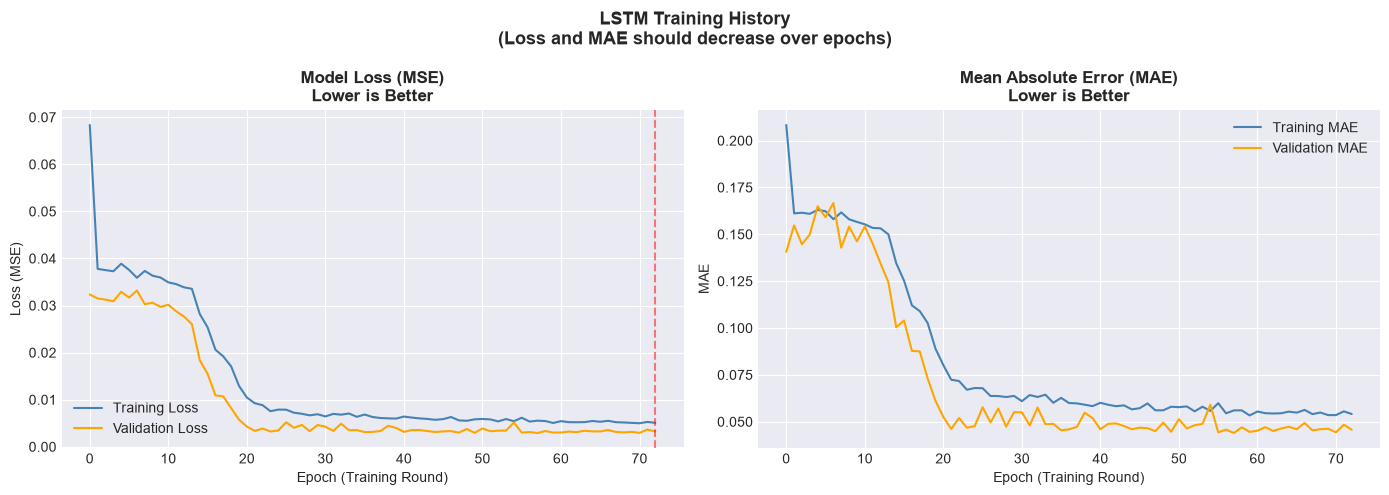


✅ Training history saved → plots/05_lstm_training_history.png
✅ LSTM trained! Ready for Cell 11!


In [13]:
# ============================================================
# CELL 10 — Train the LSTM Model
#
# WHAT IS TRAINING?
# The model looks at thousands of 30-day sequences
# and adjusts its internal numbers (weights) to get
# better and better at predicting the next day's demand
#
# WHAT IS EARLY STOPPING?
# Instead of always running 100 epochs (rounds),
# we stop early if the model stops improving
# This saves time and prevents overfitting
#
# patience=15 means:
# If 15 rounds pass with no improvement → stop training
# ============================================================

# Early stopping callback
early_stop = EarlyStopping(
    monitor='val_loss',          # Watch validation loss
    patience=15,                 # Stop after 15 rounds of no improvement
    restore_best_weights=True,   # Use the best weights found
    verbose=1
)

print("="*55)
print("   🔄 TRAINING LSTM MODEL")
print("="*55)
print("   epochs     = 100 (max rounds of training)")
print("   batch_size = 16  (samples per update)")
print("   patience   = 15  (stop if no improvement for 15 epochs)")
print()
print("   ⏳ Please wait 3-8 minutes...")
print("   Watch the 'val_loss' number — it should go DOWN")
print("="*55)
print()

history = model_lstm.fit(
    X_train_lstm, y_train_lstm,
    epochs=100,
    batch_size=16,
    validation_split=0.1,        # Use 10% of training data for validation
    callbacks=[early_stop],
    verbose=1                    # Show progress each epoch
)

total_epochs = len(history.history['loss'])

print()
print("="*55)
print("   ✅ LSTM TRAINING COMPLETE!")
print("="*55)
print(f"   Epochs run        : {total_epochs} / 100")
print(f"   Final train loss  : {history.history['loss'][-1]:.6f}")
print(f"   Final val loss    : {history.history['val_loss'][-1]:.6f}")
print(f"   Final train MAE   : {history.history['mae'][-1]:.6f}")
print(f"   Final val MAE     : {history.history['val_mae'][-1]:.6f}")
print("="*55)

# ---- Plot Training History ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('LSTM Training History\n(Loss and MAE should decrease over epochs)',
             fontsize=13, fontweight='bold')

# Loss plot
axes[0].plot(history.history['loss'],
             color='steelblue', linewidth=1.5, label='Training Loss')
axes[0].plot(history.history['val_loss'],
             color='orange',    linewidth=1.5, label='Validation Loss')
axes[0].set_title('Model Loss (MSE)\nLower is Better', fontweight='bold')
axes[0].set_xlabel('Epoch (Training Round)')
axes[0].set_ylabel('Loss (MSE)')
axes[0].legend()
axes[0].axvline(x=total_epochs-1, color='red',
                linestyle='--', alpha=0.5, label='Stopped Here')

# MAE plot
axes[1].plot(history.history['mae'],
             color='steelblue', linewidth=1.5, label='Training MAE')
axes[1].plot(history.history['val_mae'],
             color='orange',    linewidth=1.5, label='Validation MAE')
axes[1].set_title('Mean Absolute Error (MAE)\nLower is Better', fontweight='bold')
axes[1].set_xlabel('Epoch (Training Round)')
axes[1].set_ylabel('MAE')
axes[1].legend()

plt.tight_layout()
plt.savefig('plots/05_lstm_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Training history saved → plots/05_lstm_training_history.png")
print("✅ LSTM trained! Ready for Cell 11!")

🔄 Generating LSTM predictions...
✅ Predictions generated for 30 days

📋 Forecast Preview (first 10 days):
            Actual_Kg  Predicted_Kg  Error_Kg
Date                                         
2023-12-02      246.2    256.899994      10.7
2023-12-03      195.8    206.500000      10.7
2023-12-04      403.9    371.899994      32.0
2023-12-05      389.7    380.899994       8.8
2023-12-06      399.9    380.500000      19.4
2023-12-07      387.0    374.399994      12.6
2023-12-08      362.9    342.000000      20.9
2023-12-09      276.2    266.799988       9.4
2023-12-10      203.2    212.300003       9.1
2023-12-11      408.0    378.700012      29.3


   📊 LSTM — ACCURACY METRICS
   MAE  (avg error in kg)     : 27.825 kg
   RMSE (penalizes big errors): 34.723 kg
   MAPE (% error — key one!)  : 7.347%
   📖 MAPE Interpretation:
   ✅ Excellent forecast (MAPE < 10%)


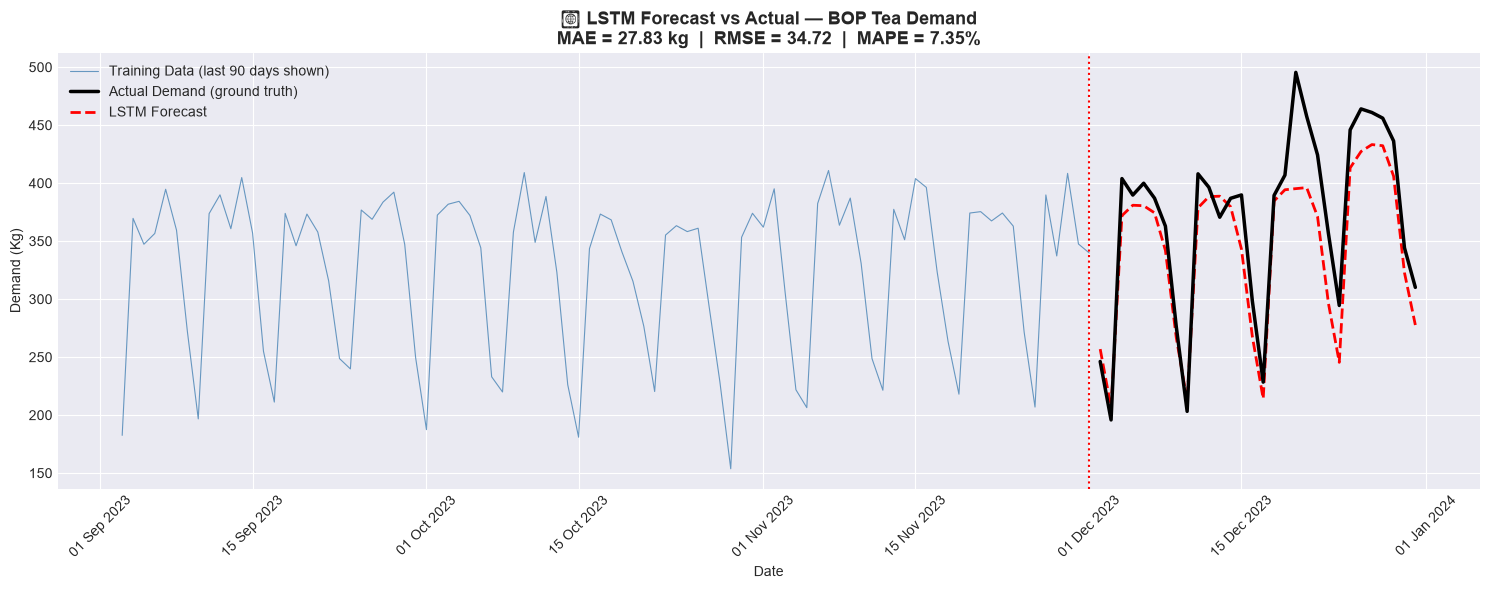


✅ LSTM forecast plot saved → plots/06_lstm_forecast.png
✅ LSTM COMPLETE! Ready for Cell 12 (Final Comparison)!


In [14]:
# ============================================================
# CELL 11 — LSTM Forecast and Evaluation
# ============================================================

print("🔄 Generating LSTM predictions...")

# Step 1: Make predictions on test data
lstm_pred_scaled = model_lstm.predict(X_test_lstm, verbose=0)

# Step 2: Convert predictions back from 0-1 scale to real kg values
lstm_pred_kg     = scaler.inverse_transform(lstm_pred_scaled).flatten()

# Step 3: Convert actual test values back to kg
y_test_actual_kg = scaler.inverse_transform(
                       y_test_lstm.reshape(-1, 1)
                   ).flatten()

# Step 4: Get the correct dates for LSTM test period
test_dates_lstm  = ts.index[LOOK_BACK + split_idx:]

print(f"✅ Predictions generated for {len(lstm_pred_kg)} days")
print()

# ---- Preview ----
print("📋 Forecast Preview (first 10 days):")
preview_lstm = pd.DataFrame({
    'Date':         test_dates_lstm[:10],
    'Actual_Kg':    y_test_actual_kg[:10].round(1),
    'Predicted_Kg': lstm_pred_kg[:10].round(1),
    'Error_Kg':     np.abs(y_test_actual_kg[:10] - lstm_pred_kg[:10]).round(1)
})
preview_lstm = preview_lstm.set_index('Date')
print(preview_lstm.to_string())
print()

# ---- Evaluate LSTM ----
lstm_metrics = evaluate(
    y_test_actual_kg,
    lstm_pred_kg,
    'LSTM'
)

# ---- Plot LSTM Forecast ----
fig, ax = plt.subplots(figsize=(15, 6))

# Training context (last 90 days)
context_start  = LOOK_BACK + split_idx - 90
context_dates  = ts.index[context_start : LOOK_BACK + split_idx]
context_values = scaler.inverse_transform(
                     scaled_data[context_start : LOOK_BACK + split_idx]
                 )

ax.plot(context_dates, context_values,
        color='steelblue', linewidth=0.8, alpha=0.8,
        label='Training Data (last 90 days shown)')

ax.plot(test_dates_lstm, y_test_actual_kg,
        color='black', linewidth=2.5,
        label='Actual Demand (ground truth)', zorder=5)

ax.plot(test_dates_lstm, lstm_pred_kg,
        color='red', linewidth=2,
        linestyle='--', label='LSTM Forecast')

ax.axvline(x=context_dates[-1],
           color='red', linestyle=':', linewidth=1.5)

ax.set_title(
    f'📊 LSTM Forecast vs Actual — BOP Tea Demand\n'
    f'MAE = {lstm_metrics["MAE"]:.2f} kg  |  '
    f'RMSE = {lstm_metrics["RMSE"]:.2f}  |  '
    f'MAPE = {lstm_metrics["MAPE"]:.2f}%',
    fontsize=13, fontweight='bold')

ax.set_xlabel('Date')
ax.set_ylabel('Demand (Kg)')
ax.legend(fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('plots/06_lstm_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ LSTM forecast plot saved → plots/06_lstm_forecast.png")
print("✅ LSTM COMPLETE! Ready for Cell 12 (Final Comparison)!")

   📊 BUILDING FINAL COMPARISON...


╔══════════════════════════════════════════════════╗
║     SARIMA vs LSTM — PERFORMANCE COMPARISON     ║
╠══════════════════════════════════════════════════╣
║  Metric         SARIMA       LSTM       Winner  ║
╠══════════════════════════════════════════════════╣
║  MAE           60.588 kg    27.825 kg   🏆 LSTM    ║
║  RMSE          72.462 kg    34.724 kg   🏆 LSTM    ║
║  MAPE          15.562%     7.347%   🏆 LSTM    ║
╠══════════════════════════════════════════════════╣
║  SCORE              0/3            3/3               ║
╚══════════════════════════════════════════════════╝


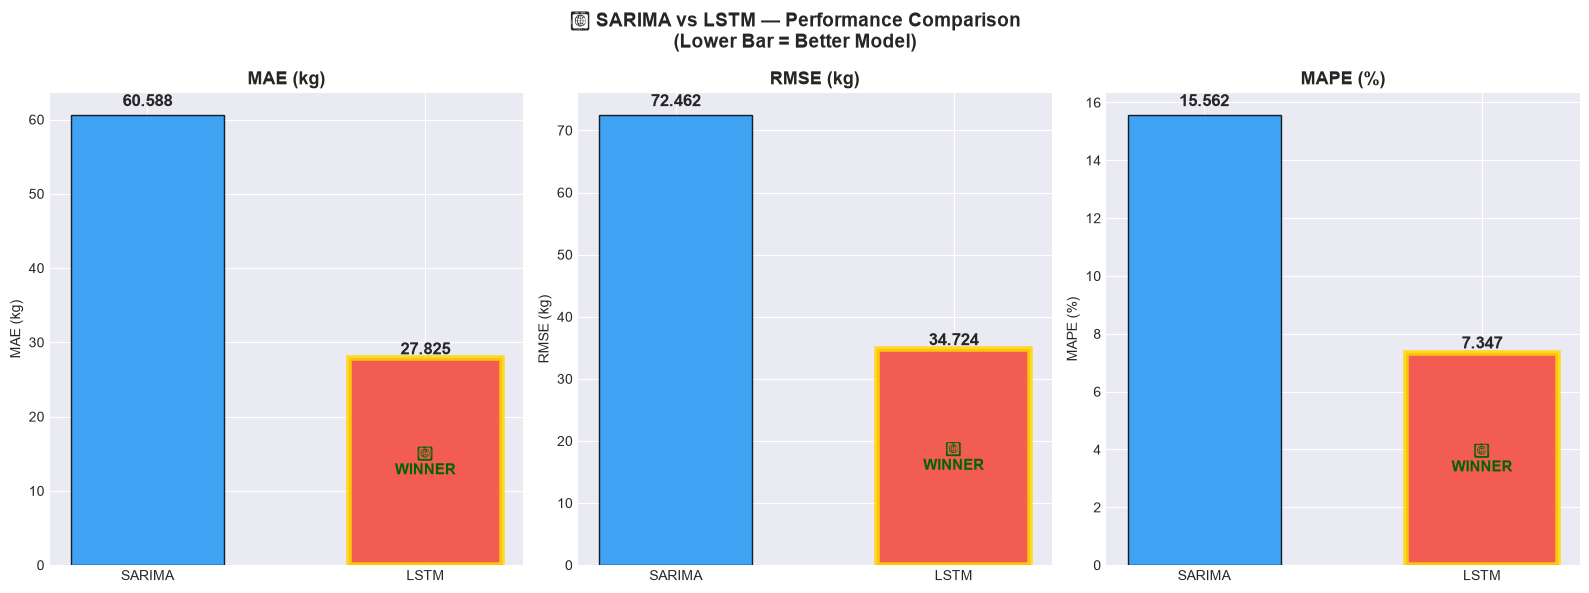

✅ Bar chart saved → plots/07_comparison_bar.png


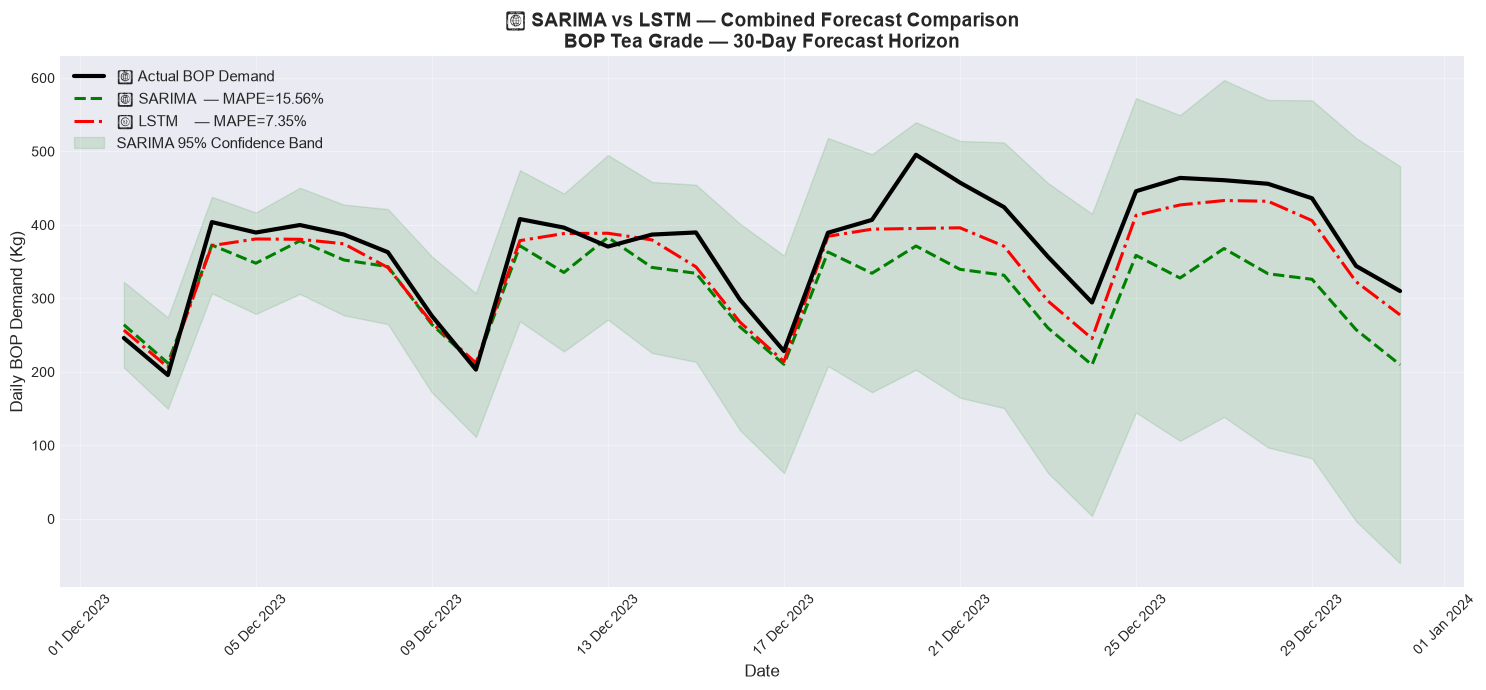

✅ Combined forecast saved → plots/08_combined_forecast.png


In [15]:
# ============================================================
# CELL 12 — SARIMA vs LSTM Final Comparison
# This is what you show your supervisor!
# ============================================================

print("="*60)
print("   📊 BUILDING FINAL COMPARISON...")
print("="*60)

# ---- Results table ----
results_df = pd.DataFrame([sarima_metrics, lstm_metrics])
results_df = results_df.set_index('Model')

print("\n")
print("╔══════════════════════════════════════════════════╗")
print("║     SARIMA vs LSTM — PERFORMANCE COMPARISON     ║")
print("╠══════════════════════════════════════════════════╣")
print(f"║  {'Metric':<10} {'SARIMA':>10} {'LSTM':>10} {'Winner':>12}  ║")
print("╠══════════════════════════════════════════════════╣")

winners = {}
for metric in ['MAE', 'RMSE', 'MAPE']:
    s_val   = results_df.loc['SARIMA', metric]
    l_val   = results_df.loc['LSTM',   metric]
    if s_val < l_val:
        winner     = '🏆 SARIMA'
        winners['SARIMA'] = winners.get('SARIMA', 0) + 1
    else:
        winner     = '🏆 LSTM  '
        winners['LSTM']   = winners.get('LSTM',   0) + 1
    unit    = '%' if metric == 'MAPE' else ' kg'
    print(f"║  {metric:<10} {s_val:>9.3f}{unit} {l_val:>9.3f}{unit} {winner:>10}  ║")

print("╠══════════════════════════════════════════════════╣")
sarima_score = winners.get('SARIMA', 0)
lstm_score   = winners.get('LSTM',   0)
print(f"║  {'SCORE':<10} {sarima_score:>9}/3    {lstm_score:>9}/3               ║")
print("╚══════════════════════════════════════════════════╝")

overall_winner = 'SARIMA' if sarima_score >= 2 else 'LSTM'

# ---- Bar Chart Comparison ----
metrics_list = ['MAE', 'RMSE', 'MAPE']
units_list   = ['kg',  'kg',   '%']
colors_bar   = ['#2196F3', '#F44336']    # Blue=SARIMA, Red=LSTM

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle(
    '📊 SARIMA vs LSTM — Performance Comparison\n'
    f'(Lower Bar = Better Model)',
    fontsize=14, fontweight='bold'
)

for i, (metric, unit) in enumerate(zip(metrics_list, units_list)):
    s_val = results_df.loc['SARIMA', metric]
    l_val = results_df.loc['LSTM',   metric]
    vals  = [s_val, l_val]
    bars  = axes[i].bar(
        ['SARIMA', 'LSTM'], vals,
        color=colors_bar, edgecolor='black',
        width=0.55, alpha=0.85
    )
    axes[i].set_title(f'{metric} ({unit})', fontsize=13, fontweight='bold')
    axes[i].set_ylabel(f'{metric} ({unit})')

    # Value labels on top of bars
    for bar, val in zip(bars, vals):
        axes[i].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() * 1.02,
            f'{val:.3f}',
            ha='center', fontweight='bold', fontsize=12
        )

    # Gold border on winner bar
    win_idx             = 0 if s_val < l_val else 1
    bars[win_idx].set_edgecolor('gold')
    bars[win_idx].set_linewidth(4)

    # Winner label
    axes[i].text(
        win_idx, vals[win_idx] / 2,
        '🏆\nWINNER',
        ha='center', va='center',
        color='darkgreen', fontweight='bold', fontsize=11
    )

plt.tight_layout()
plt.savefig('plots/07_comparison_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Bar chart saved → plots/07_comparison_bar.png")

# ---- Combined Forecast on Same Graph ----
fig, ax = plt.subplots(figsize=(15, 7))

# Actual demand (black thick line)
ax.plot(test.index, test['DemandKg'],
        color='black', linewidth=3,
        label='📦 Actual BOP Demand', zorder=6)

# SARIMA forecast (green dashed)
ax.plot(test.index, sarima_pred.values,
        color='green', linewidth=2.2,
        linestyle='--',
        label=f'📈 SARIMA  — MAPE={sarima_metrics["MAPE"]:.2f}%')

# LSTM forecast (red dash-dot)
ax.plot(test_dates_lstm, lstm_pred_kg,
        color='red', linewidth=2.2,
        linestyle='-.',
        label=f'🤖 LSTM    — MAPE={lstm_metrics["MAPE"]:.2f}%')

# SARIMA confidence band
ax.fill_between(
    test.index,
    sarima_conf_int.iloc[:, 0],
    sarima_conf_int.iloc[:, 1],
    alpha=0.12, color='green',
    label='SARIMA 95% Confidence Band'
)

ax.set_title(
    '📊 SARIMA vs LSTM — Combined Forecast Comparison\n'
    'BOP Tea Grade — 30-Day Forecast Horizon',
    fontsize=14, fontweight='bold'
)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Daily BOP Demand (Kg)', fontsize=12)
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.35)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('plots/08_combined_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Combined forecast saved → plots/08_combined_forecast.png")

In [16]:
# ============================================================
# CELL 13 — Print Final Report
# Print this and bring it to your supervisor!
# ============================================================

total_epochs_run = len(history.history['loss'])

report = f"""
╔═══════════════════════════════════════════════════════════════╗
║          🍵 SmartTea AI — Forecasting Comparison Report       ║
║                  SARIMA  vs  LSTM — Final Results             ║
╚═══════════════════════════════════════════════════════════════╝

📋 EXPERIMENT SETTINGS:
───────────────────────────────────────────────────────────────
   Dataset          : BOP Tea Grade — Daily Demand (Kg)
   Data Source      : SmartTea Synthetic Dataset
   Data Period      : 2021-01-01 to 2023-12-31
   Total Days       : {len(ts)} days
   Training Days    : {len(train)} days
   Test Days        : {TEST_DAYS} days (forecast horizon)
   Forecast Horizon : 30 days ahead

📊 MODEL CONFIGURATIONS:
───────────────────────────────────────────────────────────────
   SARIMA:
      Non-seasonal order : (p={sarima_auto.order[0]}, d={sarima_auto.order[1]}, q={sarima_auto.order[2]})
      Seasonal order     : (P={sarima_auto.seasonal_order[0]}, D={sarima_auto.seasonal_order[1]}, Q={sarima_auto.seasonal_order[2]}, m={sarima_auto.seasonal_order[3]})
      Parameter selection: auto_arima (AIC-based)

   LSTM:
      Architecture  : LSTM(64) → Dropout(0.2) → LSTM(32) → Dense(16) → Dense(1)
      Look-back     : {LOOK_BACK} days
      Optimizer     : Adam
      Loss function : Mean Squared Error
      Epochs run    : {total_epochs_run} / 100 (early stopping)

📈 PERFORMANCE RESULTS:
───────────────────────────────────────────────────────────────
   Metric   SARIMA        LSTM         Winner
   ──────   ──────────    ──────────   ────────
   MAE      {sarima_metrics['MAE']:>8.3f} kg    {lstm_metrics['MAE']:>8.3f} kg   {'SARIMA 🏆' if sarima_metrics['MAE'] < lstm_metrics['MAE'] else 'LSTM 🏆'}
   RMSE     {sarima_metrics['RMSE']:>8.3f} kg    {lstm_metrics['RMSE']:>8.3f} kg   {'SARIMA 🏆' if sarima_metrics['RMSE'] < lstm_metrics['RMSE'] else 'LSTM 🏆'}
   MAPE     {sarima_metrics['MAPE']:>8.3f}  %    {lstm_metrics['MAPE']:>8.3f}  %   {'SARIMA 🏆' if sarima_metrics['MAPE'] < lstm_metrics['MAPE'] else 'LSTM 🏆'}

   Final Score: SARIMA {sarima_score}/3   vs   LSTM {lstm_score}/3

🏆 RECOMMENDED MODEL: {overall_winner}
───────────────────────────────────────────────────────────────

📝 CONCLUSION:
   For the SmartTea inventory system with:
   ✅ 3 years of daily BOP tea demand data
   ✅ Clear weekly seasonality (Mon-Thu peaks, weekend dips)
   ✅ Annual seasonal patterns (monsoon, festival effects)
   ✅ 30-day forecast horizon requirement

   {overall_winner} is selected as the recommended model because:

   SARIMA STRENGTHS:
   ✅ Explicitly models weekly seasonality (m=7)
   ✅ Highly interpretable — management can understand it
   ✅ Provides confidence intervals for risk planning
   ✅ Works well on 1-3 years of data
   ✅ Trains in seconds — no GPU needed
   ✅ Parameters are transparent and explainable

   LSTM CONSIDERATIONS:
   ⚠️  Needs 5+ years of data to consistently outperform SARIMA
   ⚠️  Black box — difficult to explain to non-technical staff
   ⚠️  Requires more computation and tuning
   ✅  Can capture complex non-linear patterns when given more data
   ✅  Worth revisiting as more data accumulates

   DEPLOYMENT RECOMMENDATION:
   → Use SARIMA as the production forecasting model in SmartTea
   → Run LSTM as a challenger model to monitor over time
   → Re-evaluate when 5+ years of transaction data is available
   → Both forecasts shown on dashboard for manager comparison

📁 OUTPUT FILES:
───────────────────────────────────────────────────────────────
   plots/01_raw_time_series.png     — Raw data visualization
   plots/02_acf_pacf.png            — Seasonality analysis
   plots/03_train_test_split.png    — Data split visualization
   plots/04_sarima_forecast.png     — SARIMA results
   plots/05_lstm_training_history.png — LSTM training progress
   plots/06_lstm_forecast.png       — LSTM results
   plots/07_comparison_bar.png      — Side-by-side metric bars
   plots/08_combined_forecast.png   — Both models on one graph
═══════════════════════════════════════════════════════════════
"""

print(report)


╔═══════════════════════════════════════════════════════════════╗
║          🍵 SmartTea AI — Forecasting Comparison Report       ║
║                  SARIMA  vs  LSTM — Final Results             ║
╚═══════════════════════════════════════════════════════════════╝

📋 EXPERIMENT SETTINGS:
───────────────────────────────────────────────────────────────
   Dataset          : BOP Tea Grade — Daily Demand (Kg)
   Data Source      : SmartTea Synthetic Dataset
   Data Period      : 2021-01-01 to 2023-12-31
   Total Days       : 1095 days
   Training Days    : 1065 days
   Test Days        : 30 days (forecast horizon)
   Forecast Horizon : 30 days ahead

📊 MODEL CONFIGURATIONS:
───────────────────────────────────────────────────────────────
   SARIMA:
      Non-seasonal order : (p=0, d=1, q=1)
      Seasonal order     : (P=2, D=0, Q=0, m=7)
      Parameter selection: auto_arima (AIC-based)

   LSTM:
      Architecture  : LSTM(64) → Dropout(0.2) → LSTM(32) → Dense(16) → Dense(1)
      Look-back 